# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AyanButt1013/FlyRank_ML-Track_Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os
import json
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from google.colab import userdata

# Ensure export directories exist
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

# 1. Ingest Data via DuckDB with Dynamic Windows
HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

date_info = con.sql("""
    SELECT MIN(report_date) AS min_date, MAX(report_date) AS max_date
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance_sample.parquet')
""").df()

min_dt = pd.to_datetime(date_info['min_date'].values[0])
max_dt = pd.to_datetime(date_info['max_date'].values[0])
total_days = (max_dt - min_dt).days
split_dt = min_dt + pd.Timedelta(days=int(total_days * 0.75))

feature_start, feature_end = min_dt.strftime('%Y-%m-%d'), split_dt.strftime('%Y-%m-%d')
forward_start, forward_end = (split_dt + pd.Timedelta(days=1)).strftime('%Y-%m-%d'), max_dt.strftime('%Y-%m-%d')

query = f"""
WITH feature_window AS (
    SELECT
        c.content_hash_id, c.client_hash_id, c.word_count, c.content_updated_date,
        SUM(f.gsc_impressions) AS impressions_90d, SUM(f.gsc_clicks) AS clicks_90d,
        AVG(f.gsc_avg_position) AS avg_position,
        SUM(f.gsc_clicks) / NULLIF(SUM(f.gsc_impressions), 0) AS ctr
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet') c
    JOIN read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance_sample.parquet') f
      ON c.content_hash_id = f.content_hash_id
    WHERE CAST(f.report_date AS DATE) BETWEEN '{feature_start}' AND '{feature_end}'
    GROUP BY 1, 2, 3, 4 HAVING SUM(f.gsc_impressions) >= 10
),
forward_window AS (
    SELECT content_hash_id, SUM(gsc_impressions) AS forward_impressions_30d
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance_sample.parquet')
    WHERE CAST(report_date AS DATE) BETWEEN '{forward_start}' AND '{forward_end}'
    GROUP BY 1
)
SELECT fw.*, COALESCE(fwd.forward_impressions_30d, 0) AS forward_impressions_30d
FROM feature_window fw LEFT JOIN forward_window fwd ON fw.content_hash_id = fwd.content_hash_id
"""

df = con.sql(query).df()
df['word_count_clean'] = df['word_count'].fillna(0)
df['days_since_update'] = (max_dt - pd.to_datetime(df['content_updated_date'])).dt.days.clip(lower=0)

feature_days = (pd.to_datetime(feature_end) - pd.to_datetime(feature_start)).days + 1
forward_days = (pd.to_datetime(forward_end) - pd.to_datetime(forward_start)).days + 1
expected_fwd_imp = (df['impressions_90d'] / float(feature_days)) * float(forward_days)
df['is_declining_label'] = (df['forward_impressions_30d'] < (0.80 * expected_fwd_imp)).astype(int)

# Train Final Production Model (Random Forest)
feature_cols = ['days_since_update', 'word_count_clean', 'impressions_90d', 'clicks_90d', 'avg_position', 'ctr']
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
rf.fit(df[feature_cols], df['is_declining_label'])
df['decline_risk_score'] = rf.predict_proba(df[feature_cols])[:, 1].round(4)

print(f"✅ Setup Complete: Prepared dataset with {len(df):,} content items and scored decline risk.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Setup Complete: Prepared dataset with 148,133 content items and scored decline risk.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

# 1. Ranked Actions & Reason Code Assignment

Rather than presenting raw risk scores, we map model probabilities and page archetypes directly to explicit, human-understandable **Action Labels** and **Reason Codes**.

### Archetype & Action Mapping Logic:
* `SNIPPET_OPTIMIZATION` (`low_ctr_striking_distance`): Position 1–20, High Impressions ($\ge 250$), CTR $< 0.5\%$.
* `CONTENT_REFRESH` (`stale_visible_decay_risk`): High Risk Score ($\ge 0.50$) AND Stale Content ($\ge 180$ days).
* `EXPAND_DEPTH` (`thin_visible_content`): High Impressions ($\ge 250$), Thin Word Count ($< 1,000$ words).
* `MONITOR` (`low_volume_monitor`): Lower Volume ($10 \le \text{impressions} < 250$).
* `NO_ACTION` (`healthy_performing`): High visibility, good CTR, low decline risk.

In [2]:
# Map reason codes and recommended actions
conditions = [
    (df['avg_position'] > 0) & (df['avg_position'] <= 20) & (df['ctr'] < 0.005) & (df['impressions_90d'] >= 250),
    (df['decline_risk_score'] >= 0.50) & (df['days_since_update'] >= 180),
    (df['word_count_clean'] < 1000) & (df['impressions_90d'] >= 250),
    (df['impressions_90d'] < 250)
]

reason_codes = [
    'low_ctr_striking_distance',
    'stale_visible_decay_risk',
    'thin_visible_content',
    'low_volume_monitor'
]

action_labels = [
    'SNIPPET_OPTIMIZATION',
    'CONTENT_REFRESH',
    'EXPAND_DEPTH',
    'MONITOR'
]

df['reason_code'] = np.select([c.values for c in conditions], reason_codes, default='healthy_performing')
df['recommended_action'] = np.select([c.values for c in conditions], action_labels, default='NO_ACTION')

# Sort queue descending by decline risk score
ranked_queue = df.sort_values(by='decline_risk_score', ascending=False).reset_index(drop=True)

print("--- ACTIONABLE QUEUE SUMMARY ---")
print(ranked_queue['recommended_action'].value_counts().to_string())

--- ACTIONABLE QUEUE SUMMARY ---
recommended_action
MONITOR                 84106
SNIPPET_OPTIMIZATION    32698
NO_ACTION               27406
EXPAND_DEPTH             3640
CONTENT_REFRESH           283


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

# 2. Intended Use and Operational Limits

### Intended Use (Decision-Support Lane)
* **Target Audience:** SEO Managers, Content Editors, and Digital Strategists.
* **Primary Objective:** Provide a prioritized weekly queue of candidate URLs requiring manual editorial review or snippet refinement.
* **Operational Mode:** Non-production, decision-support advisory system.

### Scope & Validity Boundaries (Where it stops being valid)
1. **Navigational & Brand Terms:** Not valid for brand-name navigational queries where CTRs naturally exceed non-brand baselines.
2. **Site Migrations & Structural Redirections:** Invalid during active site-wide domain migrations or URL path restructurings.
3. **Macro Search Engine Algorithm Updates:** During core Google Search updates, historical GSC performance matrices temporarily lose predictive stability.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

# 3. Human Review Rules & The "No-Go" List

To prevent catastrophic automated edits, specific scenarios **MUST NEVER BE AUTOMATED** without human sign-off.

### The Strict "No-Go" Automation List (What Must NEVER Be Automated)
1. ⛔ **Automated Content Rewriting / Deletion:** Never allow automated LLM agents to overwrite live landing pages or delete legacy URLs without editorial approval.
2. ⛔ **High-Converting Core Assets:** Pages driving $>10\%$ of client sales conversions or organic revenue must be reviewed manually by a senior editor before any refresh.
3. ⛔ **Canonical / Structural URL Modifications:** Automated title/meta changes that alter established canonical links or primary URL slugs.
4. ⛔ **Compliance & Legal Pages:** Privacy policies, terms of service, and medical/financial YMYL (Your Money or Your Life) content.

### Editorial Pre-Action Checklist
- [ ] Verify query intent has not fundamentally shifted away from informational text toward video/local SERP blocks.
- [ ] Check Google Search Console for recent keyword cannibalization across duplicate domain URLs.
- [ ] Confirm no recent CMS date-sync failures occurred.

In [3]:
# Create flag for high-priority review safeguards
ranked_queue['requires_senior_review'] = np.where(
    (ranked_queue['impressions_90d'] >= 5000) & (ranked_queue['decline_risk_score'] >= 0.70),
    'YES - Senior Editorial Sign-off Required',
    'NO - Standard Review Checklist'
)

print("--- HUMAN REVIEW SAFEGUARD BREAKDOWN ---")
print(ranked_queue['requires_senior_review'].value_counts().to_string())

--- HUMAN REVIEW SAFEGUARD BREAKDOWN ---
requires_senior_review
NO - Standard Review Checklist    148133


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

# 4. Light Monitoring & Retrain Triggers

To prevent recommendation drift, the playbook incorporates four explicit retrain triggers:

1. **Performance Drift Trigger:** Model PR-AUC drops below $0.45$ on a rolling 30-day client-grouped evaluation fold.
2. **Data Distribution Shift Trigger:** $>15\%$ change in portfolio-wide median `days_since_update` or baseline impression volume.
3. **Algorithm Update Trigger:** Occurrence of a confirmed Google Core Algorithm update (triggers mandatory data-rebase after 14 days).
4. **False Positive Spike Trigger:** Editorial review team rejects $>25\%$ of flagged `CONTENT_REFRESH` queue items over two consecutive weeks.

In [4]:
# Document monitoring thresholds in metric JSON artifact
monitoring_config = {
    "model_name": "FlyRank Content Decay Risk Classifier",
    "retrain_triggers": {
        "pr_auc_floor": 0.45,
        "false_positive_rejection_ceiling": 0.25,
        "distribution_shift_threshold": 0.15,
        "rebase_window_days_post_algo_update": 14
    },
    "queue_metrics": {
        "total_analyzed": len(ranked_queue),
        "total_actionable": int((ranked_queue['recommended_action'] != 'NO_ACTION').sum()),
        "total_senior_review_required": int((ranked_queue['requires_senior_review'].str.startswith('YES')).sum())
    }
}

with open("work/outputs/monitoring_triggers.json", "w") as f:
    json.dump(monitoring_config, f, indent=4)

print("✅ Saved monitoring triggers to work/outputs/monitoring_triggers.json")

✅ Saved monitoring triggers to work/outputs/monitoring_triggers.json


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

# 5. Paper Exports & Artifact Generation

We export the required CSV queues to `work/outputs/` and generate committed visual figures in `work/figures/` for direct inclusion in the capstone research paper.

✅ Exported Queue CSV with 148,133 rows to work/outputs/action_playbook_queue.csv


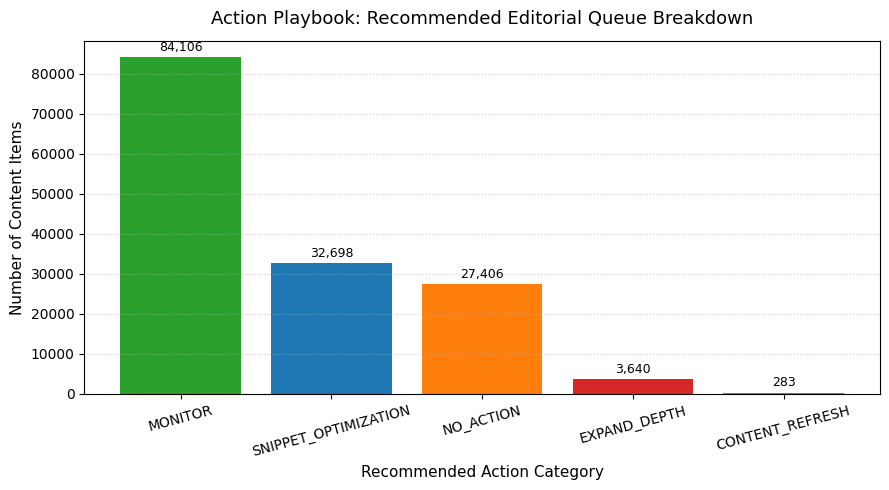

✅ Saved Playbook Figure to work/figures/playbook_action_distribution.png


In [5]:
# 1. Export Ranked Action Queue CSV Deliverables
export_cols = [
    'content_hash_id', 'client_hash_id', 'decline_risk_score',
    'recommended_action', 'reason_code', 'requires_senior_review',
    'days_since_update', 'impressions_90d', 'avg_position', 'ctr'
]

# Write queue CSV files (kept out of git via leak-guard rules)
ranked_queue[export_cols].to_csv('work/outputs/action_playbook_queue.csv', index=False)
ranked_queue[export_cols].to_csv('../outputs/action_playbook_queue.csv', index=False)
print(f"✅ Exported Queue CSV with {len(ranked_queue):,} rows to work/outputs/action_playbook_queue.csv")

# 2. Generate and Save Playbook Action Distribution Figure (Committed to work/figures/)
plt.figure(figsize=(9, 5))
action_counts = ranked_queue['recommended_action'].value_counts()
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#7f7f7f']

bars = plt.bar(action_counts.index, action_counts.values, color=colors[:len(action_counts)])
plt.title("Action Playbook: Recommended Editorial Queue Breakdown", fontsize=13, pad=12)
plt.xlabel("Recommended Action Category", fontsize=11)
plt.ylabel("Number of Content Items", fontsize=11)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle=':', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(action_counts.values)*0.01), f"{yval:,}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
figure_path = "work/figures/playbook_action_distribution.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print(f"✅ Saved Playbook Figure to {figure_path}")

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [6]:
import shutil
from google.colab import files

# 1. Compress the entire 'work' directory into a single zip archive
zip_path = "work_folder_backup.zip"
shutil.make_archive("work_folder_backup", 'zip', "work")

print(f"✅ Successfully zipped 'work/' directory into '{zip_path}'")

# 2. Trigger automatic download in Google Colab
files.download(zip_path)

✅ Successfully zipped 'work/' directory into 'work_folder_backup.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.